In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flickr8k' dataset.
Path to dataset files: /kaggle/input/flickr8k


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50,EfficientNetB0
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
import string
import re
import pickle
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Concatenate






In [3]:
images_path = "/kaggle/input/flickr8k/Images"
captions_file = "/kaggle/input/flickr8k/captions.txt"

captions_dict = {}

with open(captions_file, 'r') as f:
    for line in f:

        parts = line.strip().split(',', 1)  # split only at first comma

        if len(parts) != 2:
            continue

        img, caption = parts

        img = img.strip()
        caption = caption.strip()
        if img not in captions_dict:
            captions_dict[img] = []

        captions_dict[img].append(caption)


print("Total lines:", sum(1 for _ in open(captions_file)))
print("Unique images:", len(captions_dict))

Total lines: 40456
Unique images: 8092


In [4]:
images = list(captions_dict.keys())
captions_dict = {img: captions_dict[img] for img in images}
subset_images = images
subset_dict = {img: captions_dict[img] for img in subset_images}

image_names = list(subset_dict)
total = len(images)
total


8092

In [5]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.split()
    text = [word for word in text if len(word) > 1]
    return " ".join(text)

# Apply cleaning
for img in subset_dict:
    cleaned_captions = []

    for caption in subset_dict[img]:
        cleaned = clean_text(caption)
        cleaned_captions.append(cleaned)

    subset_dict[img] = cleaned_captions

In [6]:
all_captions = []

for img in subset_dict:
    cleaned_captions = []

    for caption in subset_dict[img]:
        cleaned = clean_text(caption)
        if not cleaned.startswith("startseq "):
          cleaned = "startseq " + cleaned
        if not cleaned.endswith(" endseq"):
            cleaned = cleaned + " endseq"
        final_caption = cleaned

        cleaned_captions.append(final_caption)
        all_captions.append(final_caption)

    subset_dict[img] = cleaned_captions

subset_dict['10815824_2997e03d76.jpg']

['startseq blonde horse and blonde girl in black sweatshirt are staring at fire in barrel endseq',
 'startseq girl and her horse stand by fire endseq',
 'startseq girl holding horse lead behind fire endseq',
 'startseq man and girl and two horses are near contained fire endseq',
 'startseq two people and two horses watching fire endseq']

In [7]:
tokenizer = Tokenizer(oov_token=None)
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
max_len = max(len(c.split()) for c in all_captions)
print(list(tokenizer.word_index.keys())[:50])

print(tokenizer.word_index.get('startseq'))
print(tokenizer.word_index.get('endseq'))
max_len = max(len(c.split()) for c in all_captions)
print(max_len)

['startseq', 'endseq', 'in', 'the', 'on', 'is', 'and', 'dog', 'with', 'man', 'of', 'two', 'white', 'black', 'boy', 'are', 'woman', 'girl', 'to', 'wearing', 'at', 'people', 'water', 'red', 'young', 'brown', 'an', 'his', 'blue', 'dogs', 'running', 'through', 'playing', 'while', 'down', 'shirt', 'standing', 'ball', 'little', 'grass', 'child', 'person', 'snow', 'jumping', 'over', 'front', 'three', 'sitting', 'holding', 'field']
1
2
34


In [8]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
cnn_model = Model(inputs=base_model.input, outputs=base_model.output)

# base_model = ResNet50(weights='imagenet', include_top=False, pooling=None)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [9]:
features = {}
missing = 0

image_names = list(subset_dict)
total = len(image_names)

batch_size = 32

for i in range(0, total, batch_size):

    batch_names = image_names[i:i + batch_size]
    images_batch = []
    names_batch = []

    # ---- load batch ----
    for img in batch_names:

        path = os.path.join(images_path, img)

        if not os.path.exists(path):
            missing += 1
            continue

        try:
            img_data = load_img(path, target_size=(224, 224))
            img_data = img_to_array(img_data)
            img_data = tf.keras.applications.resnet50.preprocess_input(img_data)

            images_batch.append(img_data)
            names_batch.append(img)

        except:
            continue

    if len(images_batch) == 0:
        continue

    images_batch = np.array(images_batch, dtype='float32')

    # ---- CNN inference ----
    batch_features = cnn_model.predict(images_batch, verbose=0)

    # ---- map features ----
    for j, name in enumerate(names_batch):
        features[name] = batch_features[j]

    # ---- PROGRESS DISPLAY (THIS IS WHAT YOU WANT) ----
    print(f"Processed {min(i + batch_size, total)} / {total}", end="\r")

print("\nDone. Missing images:", missing)

with open("features.pkl", "wb") as f:
    pickle.dump(features, f)

print("Features saved!")

Processed 8092 / 8092
Done. Missing images: 1
Features saved!


In [11]:
print(features['10815824_2997e03d76.jpg'].shape)

(2048,)


In [46]:
#Split data

image_names = list(subset_dict.keys())

split = int(0.8 * len(image_names))

train_imgs = image_names[:split]
test_imgs = image_names[split:]
train_dict = {img: subset_dict[img] for img in train_imgs}
test_dict = {img: subset_dict[img] for img in test_imgs}

In [47]:
############################          CHECKED UNTIL HERE WITH CHAT           ##########################
from tensorflow.keras.utils import to_categorical

def data_generator():

    while True:

        for img, captions in train_dict.items():

            if img not in features:
                continue

            feature = features[img]

            for cap in captions:

                seq = tokenizer.texts_to_sequences([cap])[0]

                if len(seq) < 2:
                    continue

                for i in range(1, len(seq)):

                    in_seq = seq[:i]
                    in_seq = pad_sequences([in_seq], maxlen=max_len)[0]

                    out_seq = to_categorical(seq[i], num_classes=vocab_size)
                    yield (
                        (feature, in_seq),
                        out_seq
                    )

In [48]:
output_signature = (
    (
        tf.TensorSpec(shape=(2048,), dtype=tf.float32),
        tf.TensorSpec(shape=(max_len,), dtype=tf.int32)
    ),
    tf.TensorSpec(shape=(vocab_size,), dtype=tf.float32)
)

dataset = tf.data.Dataset.from_generator(
    data_generator,
    output_signature=output_signature
)

dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [49]:
from tensorflow.keras.layers import GlobalAveragePooling2D

# image input

from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Concatenate, Flatten
from tensorflow.keras.models import Model

# image input
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# text input
inputs2 = Input(shape=(max_len,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = LSTM(256, use_cudnn=False)(se1)
se2 = Dropout(0.5)(se2)

# decoder
decoder = Concatenate()([fe2, se2])
decoder = Dense(256, activation='relu')(decoder)
outputs = Dense(vocab_size, activation='softmax')(decoder)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)

model.compile(
    loss='categorical_crossentropy',
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
)

In [50]:
# model.fit(
#     dataset,
#     epochs=25,
#     steps_per_epoch=700
# )
model.fit(dataset, epochs=40, steps_per_epoch=1500)
model.save("caption_model.keras")

import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("config.pkl", "wb") as f:
    pickle.dump({
        "max_len": max_len,
        "vocab_size": vocab_size
    }, f)

print("Saved successfully!")

Epoch 1/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 20ms/step - loss: 5.8385
Epoch 2/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 5.2845
Epoch 3/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - loss: 5.0803
Epoch 4/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 5.0040
Epoch 5/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 4.9172
Epoch 6/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 4.7378
Epoch 7/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 4.6667
Epoch 8/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - loss: 4.3667
Epoch 9/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 4.1827
Epoch 10/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 4.1708
Epoch 11/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - loss: 4.1742
Epoch 12/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 4.1921
Epoch 13/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 4.0795
Epoch 14/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - loss: 4.0826
E

In [51]:
def generate_caption(image_feature, beam_index=3, alpha=0.8, repetition_penalty=1.5):

    start_token = tokenizer.word_index['startseq']
    end_token = tokenizer.word_index['endseq']

    image_feature = np.expand_dims(image_feature, axis=0)

    sequences = [([start_token], 0.0)]

    for _ in range(max_len):

        all_candidates = []

        for seq, score in sequences:

            # stop if finished
            if seq[-1] == end_token:
                all_candidates.append((seq, score))
                continue

            seq_input = pad_sequences([seq], maxlen=max_len, padding='post')

            preds = model.predict([image_feature, seq_input], verbose=0)[0]

            # avoid zero probabilities
            preds = np.clip(preds, 1e-10, 1.0)

            # normalize probabilities
            preds = preds / np.sum(preds)

            # ---------- repetition controls ----------

            # block immediate repetition
            if len(seq) > 1:
                preds[seq[-1]] = 0

            # penalize already used words
            for word_id in set(seq):
                preds[word_id] /= repetition_penalty

            # prevent startseq from appearing again
            preds[start_token] = 0

            # renormalize
            preds = preds / np.sum(preds)

            # get top beam words
            top_words = np.argsort(preds)[-beam_index:]

            for word_id in top_words:

                prob = preds[word_id]

                # skip impossible probabilities
                if prob <= 0:
                    continue

                new_seq = seq + [word_id]

                # log probability score
                new_score = score + np.log(prob)

                all_candidates.append((new_seq, new_score))

        # sort by normalized score
        sequences = sorted(
            all_candidates,
            key=lambda x: x[1] / ((len(x[0]) + 1) ** alpha),
            reverse=True
        )[:beam_index]

        # early stopping
        if all(seq[-1] == end_token for seq, _ in sequences):
            break

    best_seq = sequences[0][0]

    caption = []

    prev_word = None

    for idx in best_seq:

        word = tokenizer.index_word.get(idx)

        if word is None:
            continue

        if word == 'endseq':
            break

        if word == 'startseq':
            continue

        # avoid duplicated consecutive words
        if word == prev_word:
            continue

        caption.append(word)
        prev_word = word

    return " ".join(caption)

In [52]:
import pickle
from tensorflow.keras.models import load_model

# model
model = load_model("caption_model.keras")

# tokenizer
tokenizer = pickle.load(open("tokenizer.pkl", "rb"))

# features
features = pickle.load(open("features.pkl", "rb"))

# config
config = pickle.load(open("config.pkl", "rb"))
max_len = config["max_len"]
vocab_size = config["vocab_size"]
# 1️⃣ FILTER VALID IMAGES
valid_captions_dict = {
    img: caps
    for img, caps in test_dict.items()
    if img in features
}

# 2️⃣ LIMIT FOR SPEED (IMPORTANT)
valid_images = list(valid_captions_dict.keys())[:100]

# 3️⃣ PREPARE STORAGE
actual, predicted = [], []

# 4️⃣ GENERATE PREDICTIONS
for i, img in enumerate(valid_images):

    if i % 10 == 0:
        print(f"Processing {i}/{len(valid_images)}")

    # predicted caption
    y_pred = generate_caption(features[img])

    # actual captions (references)
    refs = [cap.split() for cap in valid_captions_dict[img]]

    actual.append(refs)
    predicted.append(y_pred.split())

# 5️⃣ BLEU SCORES
from nltk.translate.bleu_score import corpus_bleu

bleu1 = corpus_bleu(actual, predicted, weights=(1, 0, 0, 0))
bleu2 = corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0))
bleu3 = corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0))
bleu4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))

print("\nFINAL BLEU SCORES")
print("BLEU-1:", bleu1)
print("BLEU-2:", bleu2)
print("BLEU-3:", bleu3)
print("BLEU-4:", bleu4)

Processing 0/100
Processing 10/100
Processing 20/100
Processing 30/100
Processing 40/100
Processing 50/100
Processing 60/100
Processing 70/100
Processing 80/100
Processing 90/100

FINAL BLEU SCORES
BLEU-1: 0.5168820693832589
BLEU-2: 0.3229686708118949
BLEU-3: 0.19495874688167533
BLEU-4: 0.10625772077643572


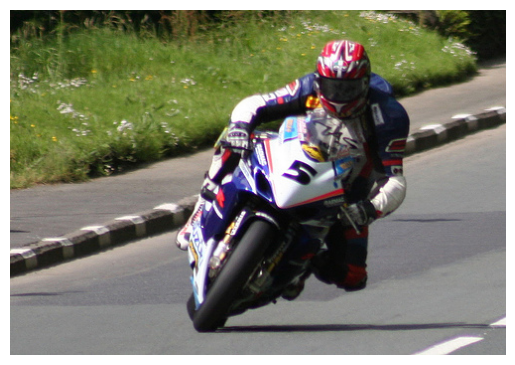


Generated Caption:
man in red helmet rides motorcycle


In [59]:

import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load pickle files
with open('features.pkl', 'rb') as f:
    features = pickle.load(f)

with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

with open('config.pkl', 'rb') as f:
    config = pickle.load(f)

# Load Keras model
caption_model = tf.keras.models.load_model('caption_model.keras')


def extract_feature(img_path):

    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.resnet50.preprocess_input(img)

    feature = cnn_model.predict(img, verbose=0)
    return feature

def predict_caption(img_path):

    # 1️⃣ extract feature
    feature = extract_feature(img_path)

    # 2️⃣ generate caption
    caption = generate_caption(feature[0])
    #caption_clean = final_clean(caption)

    return caption


# 🔥 TEST IMAGE PATH (change this)
img_path = "/kaggle/input/flickr8k/Images/161669933_3e7d8c7e2c.jpg"

# 3️⃣ show image
img = load_img(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

# 4️⃣ predict caption
caption = predict_caption(img_path)
print("\nGenerated Caption:")
print(caption)
